# 04 · Infer Nosepoke Positions (per session)

The rig does not record where each nosepoke sits in the camera image, so we infer it from
pose: at the instant the animal pokes a port, its head is at that port. Done **per session**
because the camera can shift between sessions.

Method (see [`pose_trajectory/infer_poke_positions.py`](../pose_trajectory/infer_poke_positions.py)):
1. take the head position (nose, or nose+ears centroid) at each Success/Fail poke;
2. group by the poked port and take the median → an inferred (x, y) per port;
3. ports that received a Success poke are *success-anchored* (their number is certain, since
   on a Success the poked port equals the rewarded port).

We also report an **accuracy** table (how tightly the points cluster) and the **inter-port
distances** (the ports lie on a ring, so neighbours should be roughly equally spaced).

> **Note on this dataset:** in a well-trained session most pokes land on the single rewarded
> port, so only a few ports are resolved per session. Sessions with more errors (or where the
> rewarded port varies) populate more of the ring. The richer alternative is the raw
> `nosepoke:Activations` HARP stream (every poke at every port); here we follow the
> trial-based definition.

> **Kernel:** repo `.venv`. Run `01_summary_table.ipynb` first.

## 0 · Setup and config

In [1]:
import sys
import warnings
from math import ceil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WORKSPACE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(WORKSPACE) not in sys.path:
    sys.path.insert(0, str(WORKSPACE))

from pose_trajectory import workspace
from pose_trajectory.loading import select_pose_sessions, session_movement_dataset
from data_conduit.utils.utils_core import exclude  # 'all but these' selector
from pose_trajectory.infer_poke_positions import infer_poke_positions, inter_port_distances

pd.set_option("display.max_columns", 30)
warnings.filterwarnings("ignore")

In [2]:
# ============================== EDIT THESE (match notebook 01) ==============================
DATA_ROOT = workspace.REPO_ROOT / "datasets" / "firstdata" / "BonsaiFiles"
MICE     = ["FbR_M01569522"]   # include list | exclude("X", ...) for all-but | None = all
DAYS     = ["Day 11"]          # exact day-folder names (note "Day 11" and "Day_11" both exist)
SESSIONS = None                # session-folder names to include, or None for all

USE_EAR_CENTROID = False   # False = nose tip; True = centroid of nose + both ears (steadier)

# Camera frame size in pixels (width, height). Locks every panel below to the full image so
# the sessions are directly comparable instead of each auto-zooming to its own points. Taken
# from the DLC metadata / video for this rig (720 x 540); change it if the camera differs.
FRAME_W, FRAME_H = 720, 540
# ===========================================================================================

sessions = select_pose_sessions(DATA_ROOT, mice=MICE, days=DAYS, sessions=SESSIONS, require_dlc=True)

# These notebooks write per-mouse outputs, so resolve the single selected mouse for the
# summary-table lookup and the output filenames. Select exactly one mouse above.
_mice = sorted({entry["mouse"] for entry in sessions.values()})
assert len(_mice) == 1, f"Select exactly one mouse for this notebook; selection has {_mice}"
MOUSE_ID = _mice[0]

summary = pd.read_csv(workspace.OUTPUT_DIR / f"summary_table_{MOUSE_ID}.csv")
print(f"{len(summary)} trials | {len(sessions)} sessions")

print(f'Session Keys: {list(sessions.keys())}')

109 trials | 6 sessions
Session Keys: ['2026-04-08T14-53-51', '2026-04-08T14-55-57', '2026-04-08T14-58-54', '2026-04-08T15-03-02', '2026-04-08T15-10-06', '2026-04-08T15-13-20']


## 1 · Infer positions for every session

`infer_poke_positions` needs each session's poke times, poked port, rewarded port, and
outcome. Those all live in the summary table (the poke time is `inbound_end`), so we rebuild
a small trials frame per session and pass it in alongside the session's pose.

In [3]:
position_tables, accuracy_tables = [], []
for key, entry in sessions.items():
    mov = session_movement_dataset(entry["path"])

    # Rebuild the minimal trials frame this session needs, from the summary table.
    st = summary[summary["session"] == key]
    trials_like = pd.DataFrame({
        "poke_time": st["inbound_end"].to_numpy(),    # inbound_end == poke time
        "chosen_port": st["chosen_poke"].to_numpy(),
        "correct_port": st["actual_poke"].to_numpy(),
        "outcome": st["result"].str.lower().to_numpy(),
    })

    positions, accuracy = infer_poke_positions(mov["position"], trials_like, use_ear_centroid=USE_EAR_CENTROID)
    positions = positions.reset_index(); positions.insert(0, "session", key)
    accuracy = accuracy.reset_index(); accuracy.insert(0, "session", key)
    position_tables.append(positions)
    accuracy_tables.append(accuracy)

all_positions = pd.concat(position_tables, ignore_index=True)
all_accuracy = pd.concat(accuracy_tables, ignore_index=True)
print("inferred port rows:", len(all_positions))
all_positions

inferred port rows: 8


,session,port,x,y,n_success,n_fail,n_total,success_anchored
0,2026-04-08T14-53-51,9,134.917969,282.560547,15,0,15,True
1,2026-04-08T14-55-57,9,134.647377,283.548584,16,0,16,True
2,2026-04-08T14-58-54,2,593.560913,412.167786,0,1,1,False
3,2026-04-08T14-58-54,9,134.493286,280.912781,19,0,19,True
4,2026-04-08T14-58-54,17,611.751648,155.718399,0,1,1,False
5,2026-04-08T15-03-02,9,134.446281,284.178421,20,0,20,True
6,2026-04-08T15-10-06,9,134.260910,283.680420,14,0,14,True
7,2026-04-08T15-13-20,9,134.513588,283.245499,20,0,20,True


## 2 · Accuracy of the inferred positions

`spread_px` is the mean distance of contributing pokes to the inferred position (small =
tight = reliable); `max_dev_px` is the worst such distance; `success_vs_all_px` is how far
the Success-only estimate sits from the all-trials estimate (a check that Fails are not
dragging the position).

In [4]:
all_accuracy.round(2)

,session,port,spread_px,max_dev_px,std_x,std_y,success_vs_all_px
0,2026-04-08T14-53-51,9,2.20,4.35,0.61,2.34,0.0
1,2026-04-08T14-55-57,9,2.10,4.87,0.72,2.36,0.0
2,2026-04-08T14-58-54,2,0.00,0.00,NaN,NaN,NaN
3,2026-04-08T14-58-54,9,2.21,3.90,0.89,2.26,0.0
4,2026-04-08T14-58-54,17,0.00,0.00,NaN,NaN,NaN
5,2026-04-08T15-03-02,9,1.17,5.63,0.51,1.86,0.0
6,2026-04-08T15-10-06,9,1.58,5.36,0.72,1.95,0.0
7,2026-04-08T15-13-20,9,1.89,5.23,0.95,2.18,0.0


## 3 · Visualise the inferred ring, per session

One panel per session, each inferred port plotted at its pixel position (image y points
down) and labelled with its port number. Marker size grows with the number of contributing
pokes; an open marker means the port was never success-anchored (inferred from Fails only).

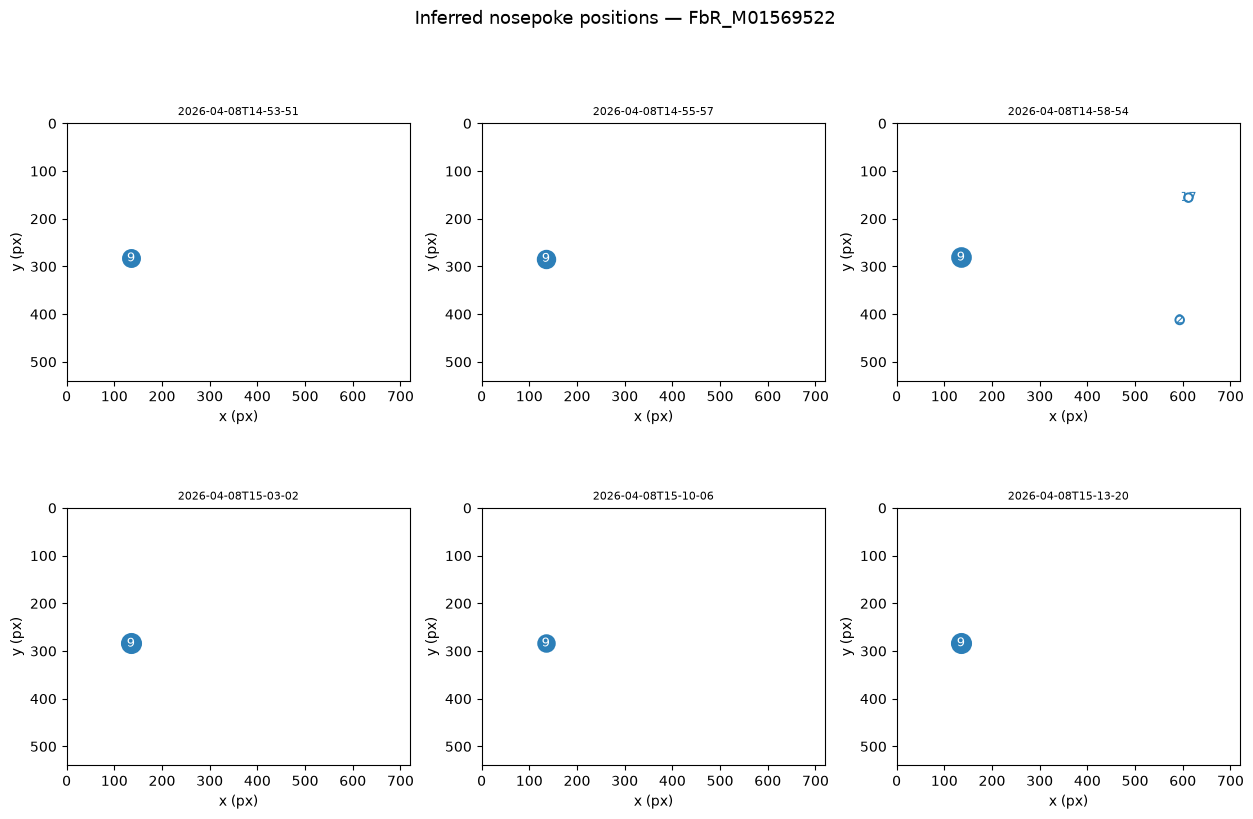

In [5]:
keys = list(sessions)
ncol = min(3, len(keys))
nrow = ceil(len(keys) / ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 4.2 * nrow), squeeze=False)

for ax, key in zip(axes.ravel(), keys):
    sub = all_positions[all_positions["session"] == key]
    for _, p in sub.iterrows():
        anchored = bool(p["success_anchored"])
        ax.scatter(p["x"], p["y"], s=30 + 8 * p["n_total"], c="#2c7fb8" if anchored else "none",
                   edgecolors="#2c7fb8", linewidths=1.4, zorder=3)
        ax.annotate(int(p["port"]), (p["x"], p["y"]), fontsize=9, ha="center", va="center",
                    color="white" if anchored else "#2c7fb8")
    ax.set_title(key, fontsize=8)
    ax.set_aspect("equal", "box")
    # Lock every panel to the full camera frame so positions are comparable across sessions.
    # Setting ylim from FRAME_H down to 0 also flips y into image coordinates (so this
    # replaces the old invert_yaxis()).
    ax.set_xlim(0, FRAME_W)
    ax.set_ylim(FRAME_H, 0)
    ax.set_xlabel("x (px)"); ax.set_ylabel("y (px)")

# Hide any unused panels.
for ax in axes.ravel()[len(keys):]:
    ax.set_axis_off()

fig.suptitle(f"Inferred nosepoke positions — {MOUSE_ID}", y=1.0, fontsize=13)
fig.tight_layout()
workspace.save_figure(fig, f"inferred_poke_positions_{MOUSE_ID}")
plt.show()

## 4 · Inter-port distances (ring spacing)

For sessions that resolved at least two ports, the nearest-neighbour spacing between
inferred ports. On the physical ring, adjacent ports are evenly spaced, so for a fully
sampled session these should be similar.

In [6]:
for key in keys:
    sub = all_positions[all_positions["session"] == key].set_index("port")[["x", "y"]]
    dists = inter_port_distances(sub)
    if len(dists):
        nn = dists[dists["nearest"]][["port_a", "port_b", "distance_px"]]
        spacings = ", ".join(f"{int(r.port_a)}→{int(r.port_b)}:{r.distance_px:.0f}px" for _, r in nn.iterrows())
        print(f"{key}: {spacings}")
    else:
        print(f"{key}: <2 ports resolved")

2026-04-08T14-53-51: <2 ports resolved
2026-04-08T14-55-57: <2 ports resolved
2026-04-08T14-58-54: 2→17:257px, 9→2:477px, 17→2:257px
2026-04-08T15-03-02: <2 ports resolved
2026-04-08T15-10-06: <2 ports resolved
2026-04-08T15-13-20: <2 ports resolved


## 5 · Save the tables

In [7]:
all_positions.to_csv(workspace.OUTPUT_DIR / f"poke_positions_{MOUSE_ID}.csv", index=False)
all_accuracy.to_csv(workspace.OUTPUT_DIR / f"poke_positions_accuracy_{MOUSE_ID}.csv", index=False)
print("saved poke_positions and accuracy tables to", workspace.OUTPUT_DIR)

saved poke_positions and accuracy tables to /home/callum/Keshavarzi-Lab-Workspace/data-conduit/Pose_Trajectory_Analysis/outputs
